# Exploratory Data Analysis — Social Media Sentiment & Hate Detection
**Project:** Social Media Sentiment & Hate Detection  
**Dataset:** [TweetEval](https://huggingface.co/datasets/cardiffnlp/tweet_eval) — `sentiment` and `hate` subsets  
**Purpose:** Week 1 EDA deliverable (Step 1.3)

---

## Overview

This notebook performs a full exploratory analysis of the TweetEval dataset before any model training. The goals are:

1. Understand data structure, schema, and label mappings.
2. Audit for missing, empty, or noisy records.
3. Visualise label distributions across all splits (train / val / test).
4. Analyse tweet length distributions to flag potential tokenisation issues.
5. Quantify class imbalance and assess whether intervention is needed.
6. Identify and quantify raw noise (URLs, unprocessed mentions) to motivate `clean_text`.

**Note:** All DataFrames created here are for analysis only. `baseline_model.ipynb` is self-contained and re-loads data independently.


## 1. Imports

In [5]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset

## 2. Dataset Loading

Both TweetEval subsets are loaded directly from HuggingFace:
- **`sentiment`** — 3-class tweet sentiment (negative / neutral / positive).
- **`hate`** — 2-class hate speech detection (non-hate / hate).

Each dataset contains three splits: `train`, `validation`, and `test`.


In [6]:
sentiment_dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")
hate_dataset = load_dataset("cardiffnlp/tweet_eval", "hate")

# Quick structural overview of each DatasetDict
print("Sentiment dataset:", sentiment_dataset)
print("Hate dataset:", hate_dataset)

Sentiment dataset: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Hate dataset: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2970
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1000
    })
})


In [7]:
# Schema inspection — feature names and label encodings
print("=== Sentiment Features ===")
print(sentiment_dataset["train"].features)
print("Label mapping: 0=negative, 1=neutral, 2=positive")

print("\n=== Hate Features ===")
print(hate_dataset["train"].features)
print("Label mapping: 0=non-hate, 1=hate")

=== Sentiment Features ===
{'text': Value('string'), 'label': ClassLabel(names=['negative', 'neutral', 'positive'])}
Label mapping: 0=negative, 1=neutral, 2=positive

=== Hate Features ===
{'text': Value('string'), 'label': ClassLabel(names=['non-hate', 'hate'])}
Label mapping: 0=non-hate, 1=hate


In [8]:
# First 5 rows of each training split
print("=== Sentiment Train Sample ===")
print(sentiment_dataset["train"][:5])

print("\n=== Hate Train Sample ===")
print(hate_dataset["train"][:5])

=== Sentiment Train Sample ===
{'text': ['"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"', '"Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"', 'Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.', "Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays", '@user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"'], 'label': [2, 1, 1, 1, 2]}

=== Hate Train Sample ===
{'text': ['@user nice new signage. Are you not concerned by Beatlemania -style hysterical crowds crongregating on you…', 'A woman who you fucked multiple times saying yo dick small is a compliment you know u hit that spot 😎', '@user @user real talk do you have eyes or were they gouged out by a rapefugee?

## 3. Missing & Noisy Data Audit

Before analysis, we audit each split for:
- **Null / empty rows** — tweets that are `None` or whitespace-only.
- **Noise** — tweets with ≤ 3 characters after stripping (too short to carry meaning).

> **Findings:**
> - Sentiment dataset: all splits are clean — no null, empty, or noisy rows.
> - Hate dataset: 2 empty rows in train, 1 in validation — these are dropped before analysis.  
>   2 noisy rows (≤ 3 chars) in train and 1 in validation — kept, since very short slurs may still carry signal.


In [9]:
# for missing/noisy values in sentiment data
for split in [sentiment_dataset["train"]["text"], sentiment_dataset["validation"]["text"], sentiment_dataset["test"]["text"]]:
    counter = 0
    noise = 0
    for tweet in split:
        if tweet is None:
            counter += 1
            continue
        tweet = tweet.strip()
        if tweet == '':
            counter += 1
        if len(tweet) <= 3 and len(tweet) > 0:
            noise += 1
    print(f"Null/None = {counter}, Noise = {noise}")

print('-----------------------------')

# for missing/noisy values in hate data
for split in [hate_dataset["train"]["text"], hate_dataset["validation"]["text"], hate_dataset["test"]["text"]]:
    counter = 0
    noise = 0
    for tweet in split:
        if tweet is None:
            counter += 1
            continue
        tweet = tweet.strip()
        if tweet == '':
            counter += 1
        if len(tweet) <= 3 and len(tweet) > 0:
            noise += 1
    print(f"Null/None = {counter}, Noise = {noise}")

Null/None = 0, Noise = 0
Null/None = 0, Noise = 0
Null/None = 0, Noise = 0
-----------------------------
Null/None = 7, Noise = 2
Null/None = 1, Noise = 1
Null/None = 0, Noise = 0


## 4. Convert to Pandas DataFrames

`set_format(type="pandas")` converts the HuggingFace Arrow tables to pandas DataFrames for easier manipulation.

A human-readable `label_name` column is added alongside the integer `label` column using the dataset's built-in `int2str` mapping.

> **Note on hate DataFrame renaming:**  
> `hate_train` and `hate_val` are renamed to `hate_train_clean` and `hate_val_clean` after dropping empty rows, following a `pandas.SettingWithCopyWarning` that arises from slice assignment on filtered views.


In [10]:
# Convert sentiment splits to pandas DataFrames
sentiment_dataset.set_format(type="pandas")
senti_train = sentiment_dataset["train"][:]
senti_val   = sentiment_dataset["validation"][:]
senti_test  = sentiment_dataset["test"][:]

# Add human-readable label column
def senti_label_to_str(label_int):
    return sentiment_dataset["train"].features["label"].int2str(label_int)

senti_train["label_name"] = senti_train["label"].apply(senti_label_to_str)
senti_val["label_name"]   = senti_val["label"].apply(senti_label_to_str)
senti_test["label_name"]  = senti_test["label"].apply(senti_label_to_str)

senti_train.head()

,text,label,label_name
0,"""QT @user In the original draft of the 7th boo...",2,positive
1,"""Ben Smith / Smith (concussion) remains out of...",1,neutral
2,Sorry bout the stream last night I crashed out...,1,neutral
3,Chase Headley's RBI double in the 8th inning o...,1,neutral
4,@user Alciato: Bee will invest 150 million in ...,2,positive


In [11]:
# Convert hate splits to pandas DataFrames
hate_dataset.set_format(type="pandas")
hate_train_raw = hate_dataset["train"][:]
hate_val_raw   = hate_dataset["validation"][:]
hate_test      = hate_dataset["test"][:]

import numpy as np

# Drop empty rows identified during the audit (2 in train, 1 in val)
hate_train_clean = (
    hate_train_raw
    .replace(r'^\s*$', np.nan, regex=True)
    .dropna(subset=['text'])
    .reset_index(drop=True)
)
hate_val_clean = (
    hate_val_raw
    .replace(r'^\s*$', np.nan, regex=True)
    .dropna(subset=['text'])
    .reset_index(drop=True)
)

# Add human-readable label column
def hate_label_to_str(label_int):
    return hate_dataset["train"].features["label"].int2str(label_int)

hate_train_clean["label_name"] = hate_train_clean["label"].apply(hate_label_to_str)
hate_val_clean["label_name"]   = hate_val_clean["label"].apply(hate_label_to_str)
hate_test["label_name"]        = hate_test["label"].apply(hate_label_to_str)

hate_train_clean.head()

,text,label,label_name
0,@user nice new signage. Are you not concerned ...,0,non-hate
1,A woman who you fucked multiple times saying y...,1,hate
2,@user @user real talk do you have eyes or were...,1,hate
3,your girlfriend lookin at me like a groupie in...,1,hate
4,Hysterical woman like @user,0,non-hate


## 5. Label Distribution Analysis

### 5.1 Raw Counts

We use `Counter` to get raw class counts across all splits before converting to DataFrames.


In [12]:
# Raw label counts for all splits
print("=== Sentiment ===")
print("Train:", Counter(sentiment_dataset["train"]["label"]))
print("Val:  ", Counter(sentiment_dataset["validation"]["label"]))
print("Test: ", Counter(sentiment_dataset["test"]["label"]))

print("\n=== Hate ===")
print("Train:", Counter(hate_dataset["train"]["label"]))
print("Val:  ", Counter(hate_dataset["validation"]["label"]))
print("Test: ", Counter(hate_dataset["test"]["label"]))

=== Sentiment ===
Train: Counter({1: 20673, 2: 17849, 0: 7093})
Val:   Counter({1: 869, 2: 819, 0: 312})
Test:  Counter({1: 5937, 0: 3972, 2: 2375})

=== Hate ===
Train: Counter({0: 5217, 1: 3783})
Val:   Counter({0: 573, 1: 427})
Test:  Counter({0: 1718, 1: 1252})


### 5.2 Normalised Proportions

Proportions reveal how class balance differs across splits — critical for identifying distribution shift.


In [13]:
# Normalised proportions for all splits (label as integer index)
print("=== Sentiment (proportions) ===")
print("Train:\n", senti_train["label"].value_counts(normalize=True))
print("Val:\n",   senti_val["label"].value_counts(normalize=True))
print("Test:\n",  senti_test["label"].value_counts(normalize=True))

print("\n=== Hate (proportions) ===")
print("Train:\n", hate_train_clean["label"].value_counts(normalize=True))
print("Val:\n",   hate_val_clean["label"].value_counts(normalize=True))
print("Test:\n",  hate_test["label"].value_counts(normalize=True))

=== Sentiment (proportions) ===
Train:
 label
1    0.453206
2    0.391297
0    0.155497
Name: proportion, dtype: float64
Val:
 label
1    0.4345
2    0.4095
0    0.1560
Name: proportion, dtype: float64
Test:
 label
1    0.483312
0    0.323347
2    0.193341
Name: proportion, dtype: float64

=== Hate (proportions) ===
Train:
 label
0    0.579339
1    0.420661
Name: proportion, dtype: float64
Val:
 label
0    0.572573
1    0.427427
Name: proportion, dtype: float64
Test:
 label
0    0.578451
1    0.421549
Name: proportion, dtype: float64


### 5.3 Bar Charts — Class Frequency per Split

Visual comparison of class frequencies for each split of both tasks.

> **Observation — Distribution Shift (Sentiment):**  
> The test split shows a significant class distribution shift:  
> - **Negative class**: rises from ~15.5% (train) to ~32.3% (test).  
> - **Positive class**: drops from ~39% (train) to ~19.3% (test).  
> This is a known TweetEval benchmark artefact — it cannot be corrected and must be documented as a limitation when reporting test results.


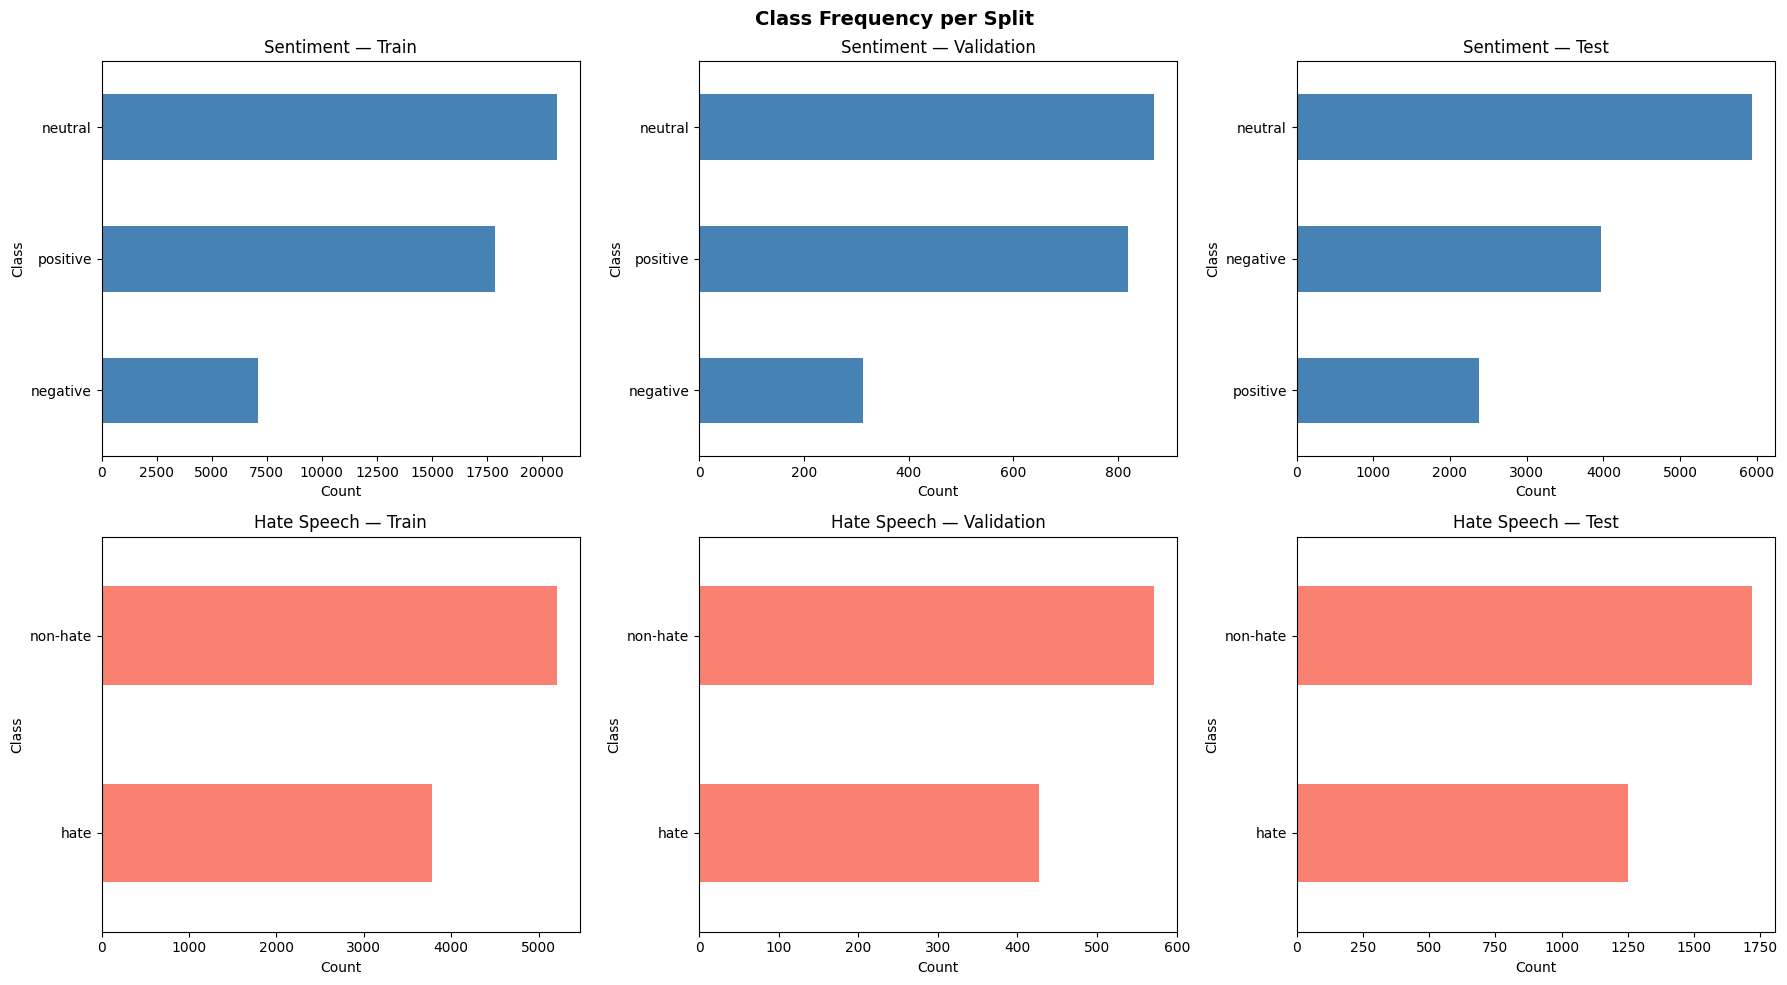

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── Sentiment ───────────────────────────────────────────────────────────
datasets_senti = [
    (senti_train, "Sentiment — Train"),
    (senti_val,   "Sentiment — Validation"),
    (senti_test,  "Sentiment — Test"),
]
for i, (df, title) in enumerate(datasets_senti):
    df["label_name"].value_counts(ascending=True).plot.barh(ax=axes[0][i], color="steelblue")
    axes[0][i].set_title(title)
    axes[0][i].set_xlabel("Count")
    axes[0][i].set_ylabel("Class")

# ── Hate ────────────────────────────────────────────────────────────────
datasets_hate = [
    (hate_train_clean, "Hate Speech — Train"),
    (hate_val_clean,   "Hate Speech — Validation"),
    (hate_test,        "Hate Speech — Test"),
]
for i, (df, title) in enumerate(datasets_hate):
    df["label_name"].value_counts(ascending=True).plot.barh(ax=axes[1][i], color="salmon")
    axes[1][i].set_title(title)
    axes[1][i].set_xlabel("Count")
    axes[1][i].set_ylabel("Class")

plt.suptitle("Class Frequency per Split", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Class Imbalance Analysis

We compute the imbalance ratio between the majority and minority class in each training split.  
A ratio > 1 means the majority class has that many more samples than the minority class.

> **Findings:**
> - **Sentiment** imbalance ratio ≈ **2.91 : 1** (neutral:negative — 20,673 vs 7,093).  
>   This is moderate imbalance. The negative class is the most vulnerable and motivates weighted-loss experiments in E3.
> - **Hate** imbalance ratio ≈ **1.38 : 1** (non-hate:hate — 5,210 vs 3,783).  
>   This is mild and not considered problematic. Hate detection issues in E1 are attributed to feature-space limitations, not imbalance.


In [15]:
# Class counts in training splits
print("=== Sentiment Train ===")
print(senti_train["label"].value_counts())

print("\n=== Hate Train ===")
print(hate_train_clean["label"].value_counts())

# Imbalance ratios (majority / minority)
sentiment_imbalance_ratio = 20673 / 7093
hate_imbalance_ratio      = 5210  / 3783

print(f"\nSentiment imbalance ratio (neutral:negative): {sentiment_imbalance_ratio:.2f}:1")
print(f"Hate imbalance ratio (non-hate:hate):          {hate_imbalance_ratio:.2f}:1")

=== Sentiment Train ===
label
1    20673
2    17849
0     7093
Name: count, dtype: int64

=== Hate Train ===
label
0    5210
1    3783
Name: count, dtype: int64

Sentiment imbalance ratio (neutral:negative): 2.91:1
Hate imbalance ratio (non-hate:hate):          1.38:1


## 7. Tweet Length Analysis

### 7.1 Word Count Histograms

We compute a simple whitespace-tokenised word count for each tweet and plot histograms across all splits.

This informs tokenisation decisions for the transformer model in E2:  
- If tweets are short, `max_length=128` tokens should be sufficient for most samples.
- Outliers (very long tweets) might be truncated.

> **Findings:**
> - Sentiment splits: max ≈ 35 words — well within 128 tokens; no truncation risk.
> - Hate splits: max ≈ 90–93 words in val/test — a minority of tweets may be truncated at 128 tokens. Flagged as a minor limitation.


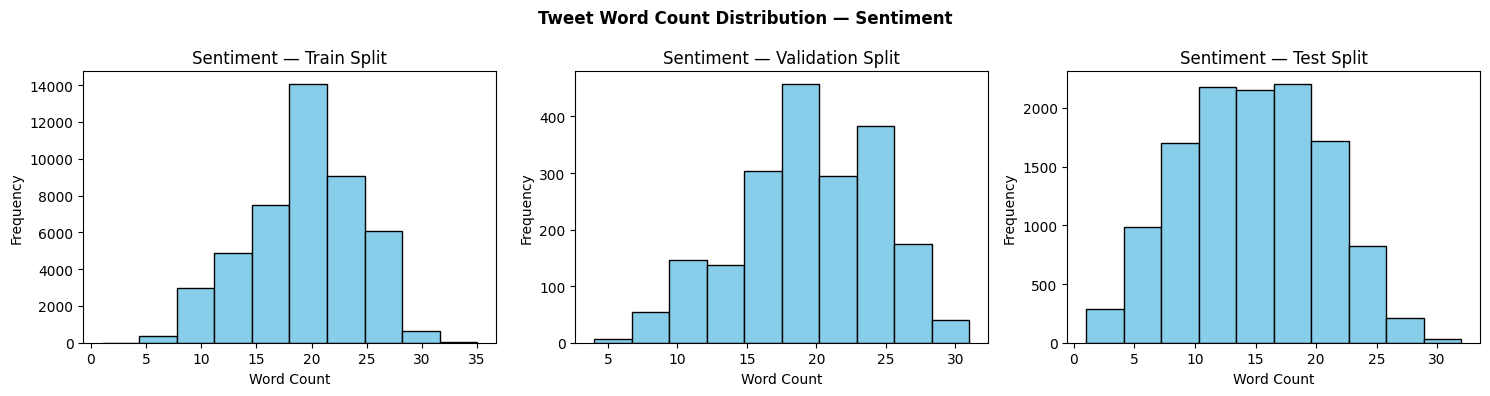

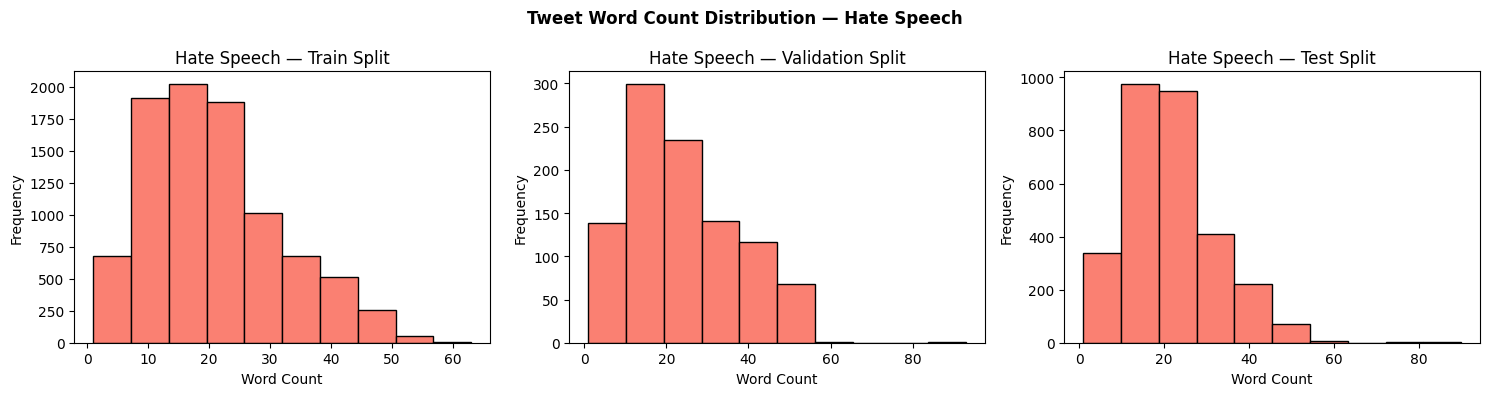

In [16]:
# Compute word counts for all splits
for df in [senti_train, senti_val, senti_test]:
    df["word_count"] = df["text"].apply(lambda x: len(x.split()))

for df in [hate_train_clean, hate_val_clean, hate_test]:
    df["word_count"] = df["text"].apply(lambda x: len(x.split()))

# ── Sentiment histograms ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, df, split in zip(axes,
                          [senti_train, senti_val, senti_test],
                          ["Train", "Validation", "Test"]):
    ax.hist(df["word_count"], color="skyblue", edgecolor="black")
    ax.set_title(f"Sentiment — {split} Split")
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
plt.suptitle("Tweet Word Count Distribution — Sentiment", fontweight="bold")
plt.tight_layout()
plt.show()

# ── Hate histograms ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, df, split in zip(axes,
                          [hate_train_clean, hate_val_clean, hate_test],
                          ["Train", "Validation", "Test"]):
    ax.hist(df["word_count"], color="salmon", edgecolor="black")
    ax.set_title(f"Hate Speech — {split} Split")
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
plt.suptitle("Tweet Word Count Distribution — Hate Speech", fontweight="bold")
plt.tight_layout()
plt.show()

### 7.2 Descriptive Statistics

Summary statistics (min, max, mean, std) for word counts across all splits.


In [17]:
# Descriptive statistics for word counts
print("=== Sentiment ===")
for name, df in [("Train", senti_train), ("Val", senti_val), ("Test", senti_test)]:
    print(f"\n{name}:")
    print(df[["word_count"]].describe().round(2).to_string())

print("\n=== Hate ===")
for name, df in [("Train", hate_train_clean), ("Val", hate_val_clean), ("Test", hate_test)]:
    print(f"\n{name}:")
    print(df[["word_count"]].describe().round(2).to_string())

=== Sentiment ===

Train:
       word_count
count    45615.00
mean        19.24
std          4.94
min          1.00
25%         16.00
50%         20.00
75%         23.00
max         35.00

Val:
       word_count
count     2000.00
mean        19.44
std          5.01
min          4.00
25%         16.00
50%         20.00
75%         23.00
max         31.00

Test:
       word_count
count    12284.00
mean        14.86
std          5.57
min          1.00
25%         11.00
50%         15.00
75%         19.00
max         32.00

=== Hate ===

Train:
       word_count
count     8993.00
mean        20.84
std         10.86
min          1.00
25%         13.00
50%         19.00
75%         27.00
max         63.00

Val:
       word_count
count      999.00
mean        24.16
std         13.03
min          1.00
25%         14.00
50%         22.00
75%         33.00
max         93.00

Test:
       word_count
count     2970.00
mean        21.41
std         10.56
min          1.00
25%         14.00
50%     

### 7.3 Word Count Distribution by Class (Box Plots)

Box plots split by class label reveal whether certain classes tend to have longer or shorter tweets — useful for understanding model behaviour.

> **Observation:** Outliers are hidden (`showfliers=False`) to focus on the interquartile range. The underlying word-count distribution shapes are similar across all classes for both tasks.


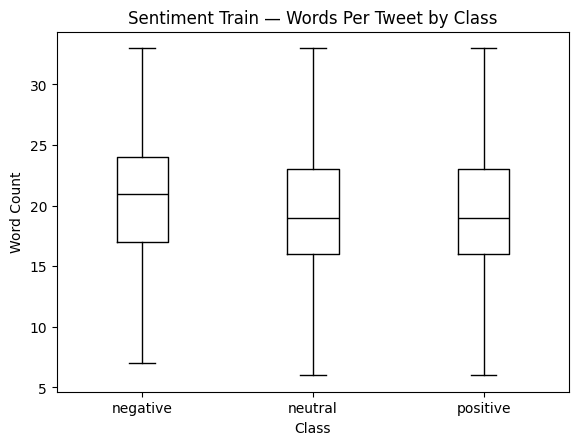

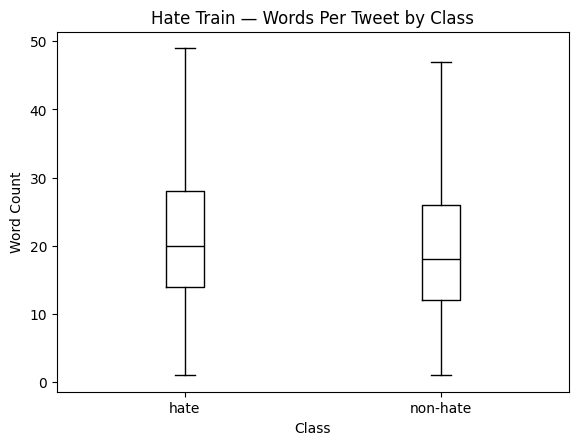

In [18]:
# Box plot: word count by class label (outliers hidden for readability)
senti_train["Words Per Tweet"] = senti_train["text"].str.split().apply(len)
ax1 = senti_train.boxplot(
    column="Words Per Tweet", by="label_name",
    grid=False, showfliers=False, color="black"
)
ax1.set_title("Sentiment Train — Words Per Tweet by Class")
ax1.set_xlabel("Class")
ax1.set_ylabel("Word Count")
plt.suptitle("")
plt.show()

hate_train_clean["Words Per Tweet"] = hate_train_clean["text"].str.split().apply(len)
ax2 = hate_train_clean.boxplot(
    column="Words Per Tweet", by="label_name",
    grid=False, showfliers=False, color="black"
)
ax2.set_title("Hate Train — Words Per Tweet by Class")
ax2.set_xlabel("Class")
ax2.set_ylabel("Word Count")
plt.suptitle("")
plt.show()

## 8. Raw Noise Audit — URLs & Unprocessed Mentions

We check how many tweets in the training splits still contain raw HTTP URLs and unprocessed `@username` mentions.  
TweetEval partially anonymises mentions (using `@user`), but coverage is not universal.

> **Findings (Train splits):**
> - **Sentiment Train:** 21 tweets with raw URLs, 359 with unprocessed mentions.
> - **Hate Train:** 125 tweets with raw URLs, 85 with unprocessed mentions.
>
> These numbers motivate steps 3 and 2 of `clean_text` (URL removal and mention anonymisation) respectively.


In [19]:
url_pattern     = r'http'
mention_pattern = r'@(?!user)\w+'

# Sentiment train
senti_train_series = pd.Series(senti_train["text"])
senti_url_count     = senti_train_series.str.contains(url_pattern,     case=False, na=False).sum()
senti_mention_count = senti_train_series.str.contains(mention_pattern, case=False, na=False).sum()

# Hate train
hate_train_series = pd.Series(hate_train_clean["text"])
hate_url_count     = hate_train_series.str.contains(url_pattern,     case=False, na=False).sum()
hate_mention_count = hate_train_series.str.contains(mention_pattern, case=False, na=False).sum()

print(f"Sentiment Train — Raw URLs: {senti_url_count}, Unprocessed mentions: {senti_mention_count}")
print(f"Hate Train      — Raw URLs: {hate_url_count}, Unprocessed mentions: {hate_mention_count}")

Sentiment Train — Raw URLs: 89, Unprocessed mentions: 359
Hate Train      — Raw URLs: 128, Unprocessed mentions: 85


## 9. EDA Summary & Conclusion

### Dataset Overview

| Property | Sentiment | Hate |
|---|---|---|
| Train size | 45,615 | 9,000 (9,000 raw → 8,998 after cleanup) |
| Validation size | 2,000 | 1,000 (1,000 raw → 999 after cleanup) |
| Test size | 12,284 | 2,970 |
| Classes | 3 (negative / neutral / positive) | 2 (non-hate / hate) |
| Max tweet length | ~35 words | ~90–93 words |

### Key Findings

1. **Data quality:** Sentiment data is clean. Hate data has 3 empty rows (2 train + 1 val), removed before analysis. Noisy rows (≤ 3 chars) are kept.

2. **Label distribution — Sentiment:**  
   - Train: neutral ≈ 45%, positive ≈ 39%, **negative ≈ 16%** (minority class).  
   - **Critical:** Test split has a significant distribution shift. Negative class jumps from ~15.5% (train) to ~32.3% (test); positive drops from ~39% to ~19.3%. This is a TweetEval artefact, not a data error. It will reduce test macro-F1 relative to val macro-F1 and must be documented as a limitation.

3. **Label distribution — Hate:** Train is only mildly imbalanced (~42% hate / ~58% non-hate, ratio ≈ 1.38 : 1). Not a concern for model training.

4. **Tweet length:** Sentiment tweets are short (max ~35 words). Hate tweets can reach ~90 words. With `max_length=128` tokens in E2, only a small fraction of hate tweets risk truncation — a minor limitation.

5. **Raw noise:** 21 raw URLs and 359 unprocessed mentions in the sentiment train split; 125 URLs and 85 mentions in the hate train split. A `clean_text` function will handle all of these.

6. **Class imbalance (train):** Sentiment ratio ≈ 2.91 : 1 (neutral:negative) — the negative class is the key minority. This directly motivates the **weighted-loss experiment in E3**. Hate ratio ≈ 1.38 : 1 — not a concern; hate detection weakness in E1 is attributed to TF-IDF's feature-space limitations, not imbalance.

### Implications for Modelling

- The `clean_text` function should be programmed in `baseline_model.ipynb` for data cleaning.
- The negative-class imbalance in sentiment and the test distribution shift are both documented and will be addressed or acknowledged in the report.
- Tokenisation at `max_length=128` is safe for sentiment; a minor truncation risk exists for hate (flagged as a limitation in E2).
- No stopword removal — "not", "never", "no" carry essential sentiment signal.
